requirements

In [46]:
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


In [47]:
import pandas as pd

In [48]:
import fonctions
import importlib
importlib.reload(fonctions)

<module 'fonctions' from '/home/ubuntu/Bureau/dm_pds/fonctions.py'>

Import des données 

In [49]:
df = pd.read_csv(
 'https://www.data.gouv.fr/fr/datasets/r/182268fc-2103-4bcb-a850-6cf90b02a9eb'
)

/tmp/ipykernel_167729/3633677116.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


Import des fonctions du fichier fonctions.py nécessaires au DM 

In [50]:
from fonctions import *

Visualisation des données

In [51]:
df.head(5)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


In [52]:
df.dtypes

code_departement       object
libelle_departement    object
code_commune            int64
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
dtype: object

In [53]:
df.sample

<bound method NDFrame.sample of        code_departement              libelle_departement  code_commune  \
0                    01                              Ain             1   
1                    01                              Ain             2   
2                    01                              Ain             4   
3                    01                              Ain             5   
4                    01                              Ain             6   
...                 ...                              ...           ...   
528670      fr_etranger  Français établis hors de France           229   
528671      fr_etranger  Français établis hors de France           231   
528672      fr_etranger  Français établis hors de France           233   
528673      fr_etranger  Français établis hors de France           234   
528674      fr_etranger  Français établis hors de France           235   

                libelle_commune    prenom      nom  voix  
0       L'Abergement

**Question 1**

*Créer ou mettre à jour les variables suivantes:*
*• code_commune: En utilisant la variable déjà existante et le département, remplacer la valeur code_commune pour constituer un vrai code commune. Par exemple, pour Montrouge, vous devriez obtenir 92049.*
*• candidat: créer une colonne avec le prenom et le nom mis ensemble, en n’oubliant pas de mettre un espace. Ne pas éliminer les bulletins abstentions, blancs ou nuls, nous allons les exploiter ultérieurement.* 

Vérification du format : pour que "01" reste "01" et ne devienne pas "1"

In [54]:
df["code_departement"] = df["code_departement"].astype(str).str.zfill(2)
df["code_commune"] = df["code_commune"].astype(str).str.zfill(3)

df["code_commune"] = df["code_departement"] + df["code_commune"]

df["candidat"] = df["prenom"].fillna("") + " " + df["nom"].fillna("")

Vérification des types d'objet et du format

In [55]:
df.dtypes

code_departement       object
libelle_departement    object
code_commune           object
libelle_commune        object
prenom                 object
nom                    object
voix                    int64
candidat               object
dtype: object

In [56]:
df.head(2)

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix,candidat
0,01,Ain,01001,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3,Nathalie ARTHAUD
1,01,Ain,01002,L'Abergement-de-Varey,Nathalie,ARTHAUD,2,Nathalie ARTHAUD


Vérification de la présence desbulletins abstentions, blancs ou nuls

In [57]:
df["candidat"].str.contains("BLANC|NUL|ABSTENTION", case=False, na=False).any()

np.True_

**Question 2**
*Compléter la phrase suivante grâce à Python: En 2022, il y avait XXXXX candidats à l’élection présidentielle*

In [58]:
fonctions.compter_candidats(df)

"En 2022, il y avait 12 candidats à l'élection présidentielle."

**Question 3**
*Calculer les scores nationaux de chaque candidat. Représenter dans ce tableau, pour chaque candidat, le nombre de voix et le pourcatage des votes exprimés (c’est à dire en retirant abstentions et votes non exprimés).*


Représentation d'un tableau donnant pour chaque candidat le nombre de voix et le pourcatage des votes exprimés


In [59]:
fonctions.scores_nationaux_2(df)


,candidat,votes,score
1,Emmanuel MACRON,9783058,27.845822
5,Marine LE PEN,8133828,23.151568
4,Jean-Luc MÉLENCHON,7712520,21.952386
11,Éric ZEMMOUR,2485226,7.073776
9,Valérie PÉCRESSE,1679001,4.778993
10,Yannick JADOT,1627853,4.633409
3,Jean LASSALLE,1101387,3.134912
2,Fabien ROUSSEL,802422,2.283959
7,Nicolas DUPONT-AIGNAN,725176,2.064091
0,Anne HIDALGO,616478,1.754701


Répresentation via great_tables

In [60]:
from great_tables import GT

GT(fonctions.scores_nationaux_2(df)).tab_header(
    title="Election Présidentielles 2022 🗳️🗳️",subtitle="Résultats du premier tour(📅 10 avril 2022)"
).cols_label(
        candidat="Candidat",
        votes="Nombre votes (total)",
        score="Score (% votes exprimés)"
    ).fmt_percent(columns="score",scale_values = False)

GT(_tbl_data=                 candidat    votes      score
1         Emmanuel MACRON  9783058  27.845822
5           Marine LE PEN  8133828  23.151568
4      Jean-Luc MÉLENCHON  7712520  21.952386
11           Éric ZEMMOUR  2485226   7.073776
9        Valérie PÉCRESSE  1679001   4.778993
10          Yannick JADOT  1627853   4.633409
3           Jean LASSALLE  1101387   3.134912
2          Fabien ROUSSEL   802422   2.283959
7   Nicolas DUPONT-AIGNAN   725176   2.064091
0            Anne HIDALGO   616478   1.754701
8         Philippe POUTOU   268904   0.765390
6        Nathalie ARTHAUD   197094   0.560995, _body=<great_tables._gt_data.Body object at 0x7fb65327b280>, _boxhead=Boxhead([ColInfo(var='candidat', type=<ColInfoTypeEnum.default: 1>, column_label='Candidat', column_align='left', column_width=None), ColInfo(var='votes', type=<ColInfoTypeEnum.default: 1>, column_label='Nombre votes (total)', column_align='right', column_width=None), ColInfo(var='score', type=<ColInfoTypeEnum.default: 1>, column_label='Score (% votes exprimés)', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7fb65014ee60>, _spanners=Spanners([]), _heading=Heading(title='Election Présidentielles 2022 🗳️🗳️', subtitle='Résultats du premier tour(📅 10 avril 2022)', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7fb652871210>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7fb6528711e0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7fb652870af0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x7fb64b2b2ce0>], _substitutions=[], _col_merge=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=OptionsInfo(scss=True, category='table', type='value', value='#A8A8A8'), table_border_right_style=OptionsInfo(scss=True, category='table', type='value', value='none'), table_border_right_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_right_color=OptionsInfo(scss=True, category='table', type='value', value='#D3D3D3'), table_border_bottom_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_bottom_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_bottom_width=OptionsInfo(scss=True, catego

**Question 4**
*Créer un dataframe nommé score_departements stockant, pour chaque département, le nombre de vote obtenu pour chaque candidat et le score (en %).*

In [61]:
fonctions.scores_departements(df)

,code_departement,candidat,votes,score
1,01,Emmanuel MACRON,92206,27.687494
5,01,Marine LE PEN,86755,26.050675
4,01,Jean-Luc MÉLENCHON,57832,17.365715
11,01,Éric ZEMMOUR,27530,8.266671
9,01,Valérie PÉCRESSE,17572,5.276497
...,...,...,...,...
1291,fr_etranger,Nicolas DUPONT-AIGNAN,7074,1.417774
1287,fr_etranger,Jean LASSALLE,5964,1.195308
1286,fr_etranger,Fabien ROUSSEL,3266,0.654573
1292,fr_etranger,Philippe POUTOU,3145,0.630322


Vérification avec le dep de l'Aude (11)

In [62]:
score_departements = fonctions.scores_departements(df)
df_11 = score_departements[score_departements["code_departement"] == "11"]
df_11

,code_departement,candidat,votes,score
125,11,Marine LE PEN,64027,30.140849
121,11,Emmanuel MACRON,43104,20.291301
124,11,Jean-Luc MÉLENCHON,42039,19.789950
131,11,Éric ZEMMOUR,18434,8.677845
123,11,Jean LASSALLE,12382,5.828853
129,11,Valérie PÉCRESSE,7350,3.460028
130,11,Yannick JADOT,6322,2.976095
120,11,Anne HIDALGO,6166,2.902658
122,11,Fabien ROUSSEL,5622,2.646569
127,11,Nicolas DUPONT-AIGNAN,4206,1.979984


**Question 5**
*Refaire le lien avec le niveau national pour comparer le score départemental avec le score national*

In [63]:
import fonctions
import importlib
importlib.reload(fonctions)
score_departements = fonctions.comparaison_nationale(df)
df_11= score_departements[score_departements["code_departement"] == "11"]

df_11

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national
120,11,Marine LE PEN,64027,30.140849,8133828,23.151568
121,11,Emmanuel MACRON,43104,20.291301,9783058,27.845822
122,11,Jean-Luc MÉLENCHON,42039,19.789950,7712520,21.952386
123,11,Éric ZEMMOUR,18434,8.677845,2485226,7.073776
124,11,Jean LASSALLE,12382,5.828853,1101387,3.134912
125,11,Valérie PÉCRESSE,7350,3.460028,1679001,4.778993
126,11,Yannick JADOT,6322,2.976095,1627853,4.633409
127,11,Anne HIDALGO,6166,2.902658,616478,1.754701
128,11,Fabien ROUSSEL,5622,2.646569,802422,2.283959
129,11,Nicolas DUPONT-AIGNAN,4206,1.979984,725176,2.064091


**Question 6**
*Création d'une variable surrepresentation qui compare, en relatif, les scores nationaux et départementaux*

In [64]:
importlib.reload(fonctions)

score_departements = fonctions.calculer_surrepresentation(df)

score_departements.head(3)

,code_departement,candidat,votes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,Emmanuel MACRON,92206,27.687494,9783058,27.845822,-0.568589
1,01,Marine LE PEN,86755,26.050675,8133828,23.151568,12.522294
2,01,Jean-Luc MÉLENCHON,57832,17.365715,7712520,21.952386,-20.893721


**Question 7**
*Créer une fonction pour représenter une figure similaire à Figure 1 pour un candidat donné des principales surreprésentations (en valeur absolue) par département.*


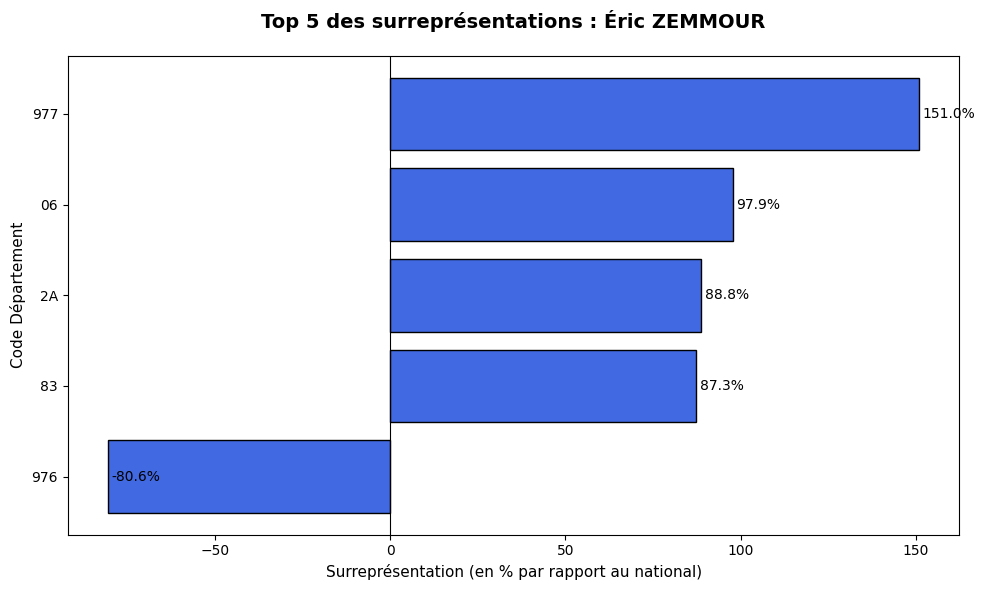

In [65]:
importlib.reload(fonctions)
fonctions.tracer_top_surrepresentations(score_departements, "Éric ZEMMOUR")

**Question 8**
*Faire une fonction permettant de restreindre score_departements en fonction d’un candidat. Commencer par tester sur Marine Le Pen (créer un nouvel objet, ne pas écraser score_departements nous allons l’utiliser à nouveau !).*
*Faire une jointure au fond de carte des départements et effectuer une carte de la représentation.*

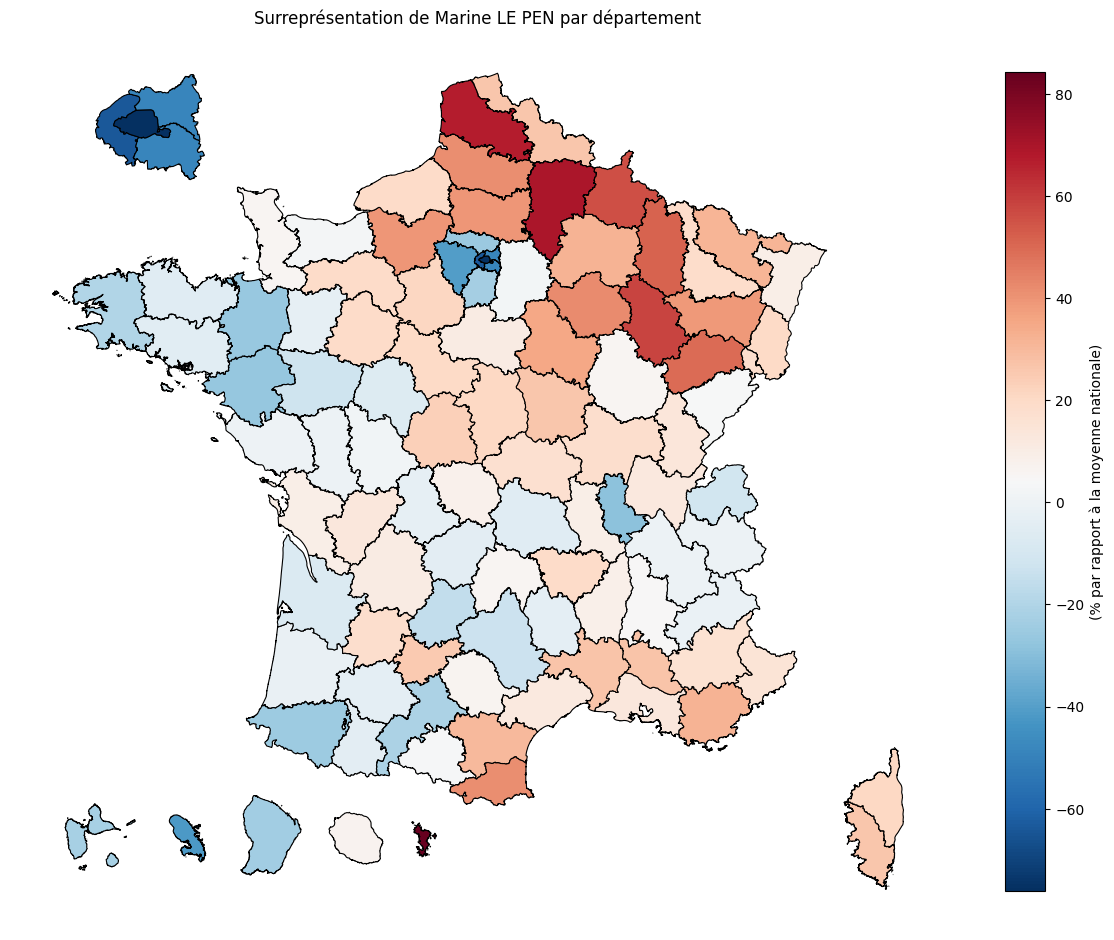

In [66]:
importlib.reload(fonctions)

tracer_carte_surrepresentation(score_departements, "Marine LE PEN")

à executer si ça marche pas 

In [67]:
dir(fonctions)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'calculer_surrepresentation',
 'carti_download',
 'comparaison_nationale',
 'compter_candidats',
 'pd',
 'plt',
 'scores_departements',
 'scores_nationaux_2',
 'tracer_carte_surrepresentation',
 'tracer_top_surrepresentations']